TERMODINÂMICA DE CÉLULAS GALVÂNICAS

In [81]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

from uncertainties import ufloat

In [16]:
#dados para regressão linear
temperatura_lista = [49, 46, 43, 40, 37, 34, 31, 28, 25, 22]
temperatura_kelvin = []
for temp in temperatura_lista:
    t = temp + 273.15
    temperatura_kelvin.append(t)

temperatura = np.array([temperatura_kelvin])
temperatura = np.reshape(temperatura_kelvin, (-1,1))

replicata1 = [1.161, 1.167, 1.174, 1.180, 1.187, 1.194, 1.200, 1.205, 1.211, 1.219]
replicata2 = [1.156, 1.163, 1.169, 1.174, 1.180, 1.186, 1.194, 1.198, 1.205, 1.212]

#dados para regressão quadrática

In [17]:
#regressões lineares
reg1 = LinearRegression()
reg1.fit(temperatura, replicata1)
a1 = reg1.coef_[0]
b1 = reg1.intercept_

reg2 = LinearRegression()
reg2.fit(temperatura, replicata2)
a2 = reg2.coef_[0]
b2 = reg2.intercept_

print(f'Equação linear 1: y = {round(a1,5)}*x + {round(b1,5)}')
print(f'Equação linear 2: y = {round(a2,5)}*x + {round(b2,5)}')

Equação linear 1: y = -0.00213*x + 1.84576
Equação linear 2: y = -0.00204*x + 1.81285


In [18]:
#regressões quadráticas
poli = PolynomialFeatures(degree = 2, include_bias = False)
temperatura_p = poli.fit_transform(temperatura)

reg_p1 = LinearRegression()
reg_p1.fit(temperatura_p, replicata1)
a11p = reg_p1.coef_[0] 
a12p = reg_p1.coef_[1]
b1p = reg_p1.intercept_

reg_p2 = LinearRegression()
reg_p2.fit(temperatura_p, replicata2)
a21p = reg_p2.coef_[0] 
a22p = reg_p2.coef_[1]
b2p = reg_p2.intercept_

print(f'Equação quadrática 1: y = {round(a12p,10)}x² + {round(a11p,5)}x + {round(b1p,5)}')
print(f'Equação quadrática 2: y = {round(a22p,10)}x² + {round(a21p,5)}x + {round(b2p,5)}')

Equação quadrática 1: y = -2.9461e-06x² + -0.00031x + 1.56532
Equação quadrática 2: y = 3.7879e-06x² + -0.00438x + 2.17342


In [19]:
#Calculando entropia para a regressao linear

def entropia(n, F, dEdT):
    DS = n * F * dEdT
    return DS

li1 = entropia(2, 96485.3321, -0.00213)
li2 = entropia(2, 96485.3321, -0.00204)
media = np.mean([li1, li2])
erro_padrao = np.std([li1, li2], ddof=1)/np.sqrt(2)

print(f'Variação de Entropia para replicata 1: {round(li1,2)}')
print(f'Variação de Entropia para replicata 2: {round(li2,2)}')
print(f'Variação média de entropia: {round(media,2)} J/K ± {round(erro_padrao,2)}')

Variação de Entropia para replicata 1: -411.03
Variação de Entropia para replicata 2: -393.66
Variação média de entropia: -402.34 J/K ± 8.68


In [50]:
#Calculando a entropia para as regressões polinomiais

lista_entropia_1 = []
lista_entropia_2 = []

lista_medias = []
lista_errop = []

def entropiapoli(n, F, T, a, b):
    DS = n * F * (T*a + b)
    return DS

for temp in temperatura_kelvin:

    S1 = entropiapoli(2, 96485.3321, temp, -5.8922*0.000001, -0.00031)
    S2 = entropiapoli(2, 96485.3321, temp, 7.5758*0.000001, -0.00438)

    lista_entropia_1.append(S1)
    lista_entropia_2.append(S2)

media1 = np.mean(lista_entropia_1)
media2 = np.mean(lista_entropia_2)

print(f'Média 1: {round(media1,2)}')
print(f'Média 2: {round(media2,2)}')
print(f'Média final: {round(np.mean([media1, media2]),2)} ± {round(np.std([media1,media2],ddof=1)/np.sqrt(2),2)}')


Média 1: -410.76
Média 2: -393.99
Média final: -402.38 ± 8.38


In [21]:
#Erros de comparação

media_final1 = -402.38 #para a polinomial
media_final2 = -402.34 #para a linear
erro_padrao1 = 8.38
erro_padrao2 = 8.86

erro_final = (media_final2 - media_final1)/media_final1 * 100
erro_final

-0.009940851931015572

In [22]:
#Salvando entropia:

replicatas = [1 , 2]
medias_linear = [-411.03, -393.66]
medias_polinomial = [-410.76, -393.99]


dados = {
    'Replicata' : replicatas,
    'Valores ΔS linear (J/K)' : medias_linear,
    'Média ΔS quadrática (J/K)' : medias_polinomial
}

erro = ((-402.34 - (-402.38))/-402.38) * 100
mediafinallinear = -402.34
mediafinalquad = -402.38

dados2 = {
    'Média final ΔS linear (J/K)' : f'{mediafinallinear} ± 8.68',
    'Média final ΔS quadrático (J/K)' : f'{mediafinalquad} ± 8.38',
    'Erro (Linear/Quadratico) (%)' : f'{round(erro,3)} ± 3.00'
}

df1 = pd.DataFrame(dados)
df2 = pd.DataFrame(dados2, index = [0])
df2

,Média final ΔS linear (J/K),Média final ΔS quadrático (J/K),Erro (Linear/Quadratico) (%)
0,-402.34 ± 8.68,-402.38 ± 8.38,-0.01 ± 3.00


In [55]:
listaDG1 = []
listaDG2 = []
listaDH1 = []
listaDH2 = []

mediaDG = []
erroPD = []
mediaDH = []
erroPH = []

for valor in zip(replicata1, replicata2, temperatura_kelvin):

    #Gibbs para replicatas 1 e 2
    DG1 = -2 * 96485.3321 * ufloat(valor[0], 0.001) / 1000
    DG2 = -2 * 96485.3321 * ufloat(valor[1], 0.001) / 1000 

    listaDG1.append(f"{DG1:.2u}")
    listaDG2.append(f"{DG2:.2u}")

    mediaG = np.mean([DG1, DG2])
    
    mediaDG.append(f"{mediaG:.2u}")
    
    #Entropia para replicatas 1 e 2
    DH1 = DG1 + ((ufloat(valor[2],0.5) * ufloat(-402.34, 8.68))/1000)
    DH2 = DG2 + ((ufloat(valor[2],0.5) * ufloat(-402.34, 8.68))/1000)
    
    listaDH1.append(DH1)
    listaDH2.append(DH2)

    mediaH = np.mean([DH1, DH2])

    mediaDH.append(mediaH)

In [56]:
dados = {
    "Temperatura (C)" : temperatura_lista,
    "ΔG (kJ): replicata 1" : listaDG1,
    "ΔG (kJ): replicata 2" : listaDG2,
    "Média ΔG (kJ)" : mediaDG,
    "ΔH (kJ): replicata 1" :listaDH1,
    "ΔH (kJ): replicata 2" :listaDH2,
    "Média ΔH (kJ)" : mediaDH,
}

df1 = pd.DataFrame(dados)
df1


,Temperatura (C),ΔG (kJ): replicata 1,ΔG (kJ): replicata 2,Média ΔG (kJ),ΔH (kJ): replicata 1,ΔH (kJ): replicata 2,Média ΔH (kJ)
0,49,-224.04+/-0.19,-223.07+/-0.19,-223.56+/-0.14,-353.7+/-2.8,-352.7+/-2.8,-353.2+/-2.0
1,46,-225.20+/-0.19,-224.42+/-0.19,-224.81+/-0.14,-353.6+/-2.8,-352.8+/-2.8,-353.2+/-2.0
2,43,-226.55+/-0.19,-225.58+/-0.19,-226.07+/-0.14,-353.7+/-2.8,-352.8+/-2.8,-353.3+/-2.0
3,40,-227.71+/-0.19,-226.55+/-0.19,-227.13+/-0.14,-353.7+/-2.7,-352.5+/-2.7,-353.1+/-1.9
4,37,-229.06+/-0.19,-227.71+/-0.19,-228.38+/-0.14,-353.8+/-2.7,-352.5+/-2.7,-353.2+/-1.9
5,34,-230.41+/-0.19,-228.86+/-0.19,-229.64+/-0.14,-354.0+/-2.7,-352.4+/-2.7,-353.2+/-1.9
6,31,-231.56+/-0.19,-230.41+/-0.19,-230.99+/-0.14,-353.9+/-2.7,-352.8+/-2.7,-353.4+/-1.9
7,28,-232.53+/-0.19,-231.18+/-0.19,-231.85+/-0.14,-353.7+/-2.6,-352.3+/-2.6,-353.0+/-1.9
8,25,-233.69+/-0.19,-232.53+/-0.19,-233.11+/-0.14,-353.6+/-2.6,-352.5+/-2.6,-353.1+/-1.8
9,22,-235.23+/-0.19,-233.88+/-0.19,-234.56+/-0.14,-354.0+/-2.6,-352.6+/-2.6,-353.3+/-1.8


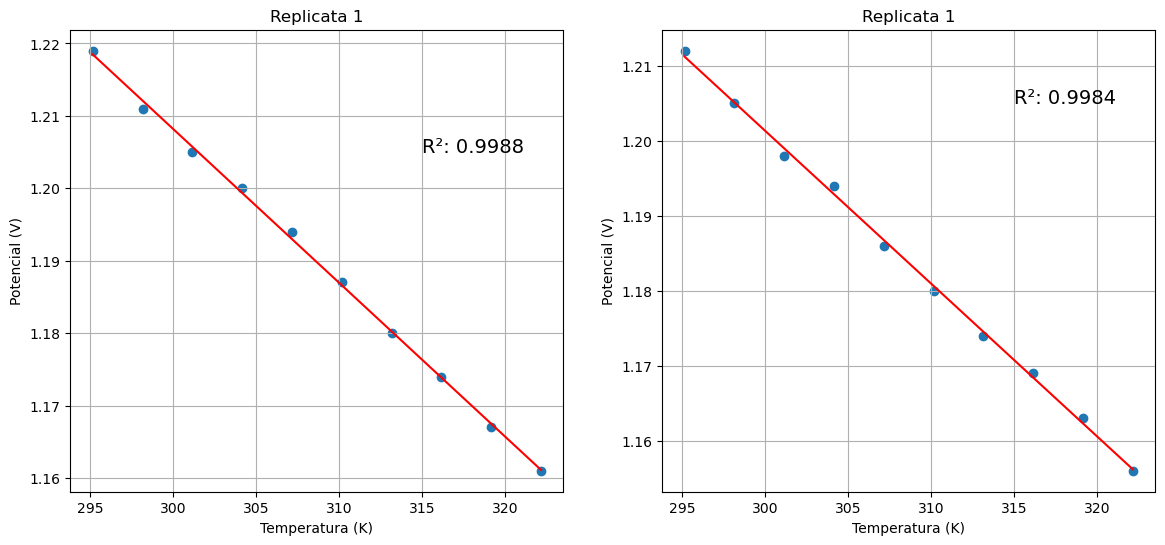

In [95]:
#Plots

r1 = r2_score(replicata1, temperatura_kelvin*reg1.coef_ + reg1.intercept_)
r2 = r2_score(replicata2, temperatura_kelvin*reg2.coef_ + reg2.intercept_)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6))

ax1.set_title('Replicata 1')
ax1.set_xlabel('Temperatura (K)')
ax1.set_ylabel('Potencial (V)')
ax1.scatter(temperatura_kelvin, replicata1)
ax1.plot(temperatura_kelvin, temperatura_kelvin*reg1.coef_ + reg1.intercept_, color = 'red')
ax1.grid(True)
ax1.text(
    x = 315,
    y = 1.205,
    s = f'R²: {round(r1, 4)}',
    fontsize = 14
)

ax2.set_title('Replicata 1')
ax2.set_xlabel('Temperatura (K)')
ax2.set_ylabel('Potencial (V)')
ax2.scatter(temperatura_kelvin, replicata2)
ax2.plot(temperatura_kelvin, temperatura_kelvin*reg2.coef_ + reg2.intercept_, color = 'red')
ax2.grid(True)
ax2.text(
    x = 315,
    y = 1.205,
    s = f'R²: {round(r2, 4)}',
    fontsize = 14
)

fig.savefig('plot.png')